## Purpose : This is for average hours per season plot with nasa blue in background map

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.02/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


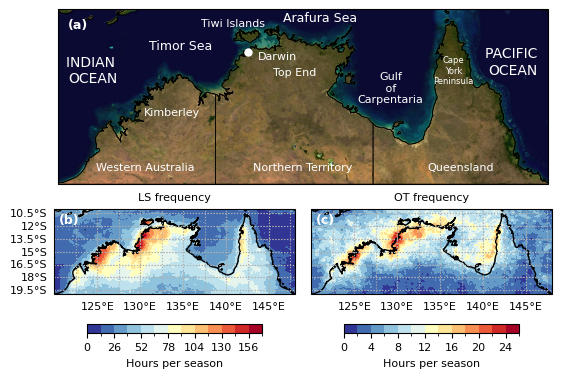

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
from matplotlib import colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box
import cartopy.io.shapereader as shpreader
import xarray as xr
import numpy as np
import matplotlib.ticker as mticker

# already gridded Overshooting top and lightning data for plotting this figure 
warm_ot = xr.open_dataset("/g/data/if69/tp4064/Project_1/OT/warm_season_NT_data/warm_season_OT.nc")
warm_ls = xr.open_dataset("/g/data/if69/tp4064/Project_1/Lightning/warm_season_LS_NT/warm_season_LS.nc")

# ---------------------- PARAMETERS ----------------------
lat_min, lat_max = -20, -10
lon_min, lon_max = 120, 148


# Contour levels — dynamic based on data min/max
n_levels_ot =  14  # number of boundaries (same as original len(levels_ot))
n_levels_ls = 14   # number of boundaries (same as original len(levels_ls))

levels_ot = np.linspace(0, 26, n_levels_ot) 
levels_ls = np.linspace(0, 169, n_levels_ls) 

# Colormaps
cmap_ot = plt.get_cmap('RdYlBu_r', len(levels_ot)-1)
cmap_ls = plt.get_cmap('RdYlBu_r', len(levels_ls)-1)
norm_ot = colors.BoundaryNorm(boundaries=levels_ot, ncolors=len(levels_ot)-1)
norm_ls = colors.BoundaryNorm(boundaries=levels_ls, ncolors=len(levels_ls)-1)


# ---------------------- MAP DATA ----------------------
# Load Australia states shapefile
fn = shpreader.natural_earth('10m', 'cultural', 'admin_1_states_provinces')
reader = shpreader.Reader(fn)
states = [x for x in reader.records() if x.attributes["admin"] == "Australia"]

clip_box = box(lon_min, lat_min, lon_max, lat_max)
clipped_geoms = [s.geometry.intersection(clip_box) for s in states]
states_geom = cfeature.ShapelyFeature(clipped_geoms, ccrs.PlateCarree())


# ---------------------- FIGURE ----------------------
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})

# GridSpec for mixed layout


# ---------------------- PANEL (a): MAP ----------------------

from PIL import Image

# 1. Expand Python's internal pixel limit to handle your large map image
# Your image has 288,000,000 pixels, so we set the ceiling to 400,000,000
Image.MAX_IMAGE_PIXELS = 400000000

# external blue marble image from nasa
image_path = "/g/data/if69/tp4064/Project_1/Whole_world_-_land_and_oceans_12000.jpg"

fig = plt.figure(figsize=(5.5, 7.5),layout='compressed')  # Full width, taller height
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.00, wspace=0.00)
# gs = fig.add_gridspec(2, 2, hspace=0.01, wspace=0.1)
# ---------------------- PANEL (a): MAP ----------------------
ax_map = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree())
ax_map.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax_map.imshow(
    plt.imread(image_path), 
    origin='upper', 
    extent=[-180, 180, -90, 90], 
    transform=ccrs.PlateCarree()
)


ax_map.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor='black')
ax_map.add_feature(states_geom, facecolor="none", edgecolor="black", linewidth=0.5)
ax_map.add_feature(cfeature.BORDERS, color="k", lw=0.4)


# Label states
from matplotlib import patheffects as PathEffects

label_positions = {
    "Western Australia": (125, -19),
    "Northern Territory": (134, -19),
    "Queensland": (143, -19),
}
for state in states:
    name = state.attributes["name"]
    if name in label_positions:
        lon, lat = label_positions[name]
        ax_map.text(lon, lat, name, size=8, transform=ccrs.PlateCarree(),
                    ha="center", va="center", color = 'white')
                    # path_effects=[PathEffects.withStroke(linewidth=4, foreground="white")])

# Region labels: name -> (lon, lat, fontsize)
region_labels = {
    "Kimberley":               (126.5, -15.9, 8),
    "Gulf\n of \nCarpentaria":  (139, -14.5, 8),
    "Tiwi Islands":             (130, -10.8, 8),
    "INDIAN \nOCEAN":           (122, -13.5, 10),
    "PACIFIC \nOCEAN":          (146, -13, 10),
    "Timor Sea":                (127, -12.1, 9),
    "Arafura Sea":              (135, -10.5, 9),
    # "Joseph \nBonaparte\nGulf": (128.4, -13.6, 7),
    "Top End":                  (133.5, -13.6, 8),
    "Cape\nYork\nPeninsula":    (142.6, -13.5, 6),
    # "Coral\nSea":               (147, -15, 9),
}

for name, (lon, lat, fontsize) in region_labels.items():
    ax_map.text(
        lon, lat, name,
        size=fontsize,
        color="white",
        transform=ccrs.PlateCarree(),
        ha="center", va="center"
    )

# Darwin marker — same size as Kimberley (8)
darwin_lon, darwin_lat = 130.8456, -12.4634
ax_map.plot(darwin_lon, darwin_lat, marker='o', markersize=5, color='white', transform=ccrs.PlateCarree())
ax_map.text(darwin_lon + 0.6, darwin_lat - 0.2, "Darwin", color='white', fontsize=8,
            transform=ccrs.PlateCarree(), va='center')

# Panel label
ax_map.text(0.02, 0.95, '(a)', transform=ax_map.transAxes, fontsize=9, color = 'white', fontweight='bold', va='top')

# ---------------------- PANEL (b): LS ----------------------
ax_ls = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
ax_ls.coastlines(resolution='10m')
ax_ls.add_feature(cfeature.BORDERS, linestyle=':')

# warm_ds = (lightning_data.sel(time=lightning_data['time'].dt.month.isin([10,11,12,1,2,3,4])).sum("time").compute())

im_ls = (warm_ls['lightning_count']/8).plot.contourf(
    levels=levels_ls,
    ax=ax_ls,
    add_colorbar=False,
    cmap=cmap_ls,
    norm=norm_ls,
    transform=ccrs.PlateCarree()
)
# divide by 8 to accommodate for 8 full warm seasons.

ax_ls.set_extent([lon_min, lon_max, lat_min+0.1, lat_max], crs=ccrs.PlateCarree())
gl_dense = ax_ls.gridlines(linestyle=':', draw_labels={"bottom": False, "left": False})
gl_dense.xlocator = mticker.MultipleLocator(2.5)
gl_dense.ylocator = mticker.MultipleLocator(1.5)


gl = ax_ls.gridlines(linestyle=':', draw_labels={"bottom": True, "left": True})

gl.xlabel_style = {'size': 8}
gl.ylabel_style = {'size': 8}

cb_ls = fig.colorbar(im_ls, ax=ax_ls, orientation='horizontal', pad=0.001, fraction=0.1)
cb_ls.set_label("Hours per season", fontsize = 8)
cb_ls.ax.tick_params(labelsize=8, rotation = 0)

ax_ls.set_title('LS frequency', pad=6, fontsize=8)
ax_ls.text(0.02, 0.95, '(b)', transform=ax_ls.transAxes, fontsize=9,color = 'white', fontweight='bold', va='top')

# ---------------------- PANEL (c): OT ----------------------
ax_ot = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())
ax_ot.coastlines(resolution='10m')
ax_ot.add_feature(cfeature.BORDERS, linestyle=':')

# warm_ot = (final_dataset.sel(time=final_dataset['time'].dt.month.isin([10,11,12,1,2,3,4]))).sum("time").compute()

im_ot = (warm_ot['ot_probability']/8).plot.contourf(
    levels=levels_ot,
    ax=ax_ot,
    add_colorbar=False,
    cmap=cmap_ot,
    norm=norm_ot,
    transform=ccrs.PlateCarree()
)

ax_ot.set_extent([lon_min, lon_max, lat_min+0.1, lat_max], crs=ccrs.PlateCarree())
gl1 = ax_ot.gridlines(linestyle=':', draw_labels={"bottom": True, "left": False})
gl1_dense = ax_ot.gridlines(linestyle=':', draw_labels={"bottom": False, "left": False})
gl1_dense.xlocator = mticker.MultipleLocator(2.5)
gl1_dense.ylocator = mticker.MultipleLocator(1.5)

gl1.xlabel_style = {'size': 8}
gl1.ylabel_style = {'size': 8}

cb_ot = fig.colorbar(im_ot, ax=ax_ot, orientation='horizontal', pad=0.001, fraction=0.1)
cb_ot.set_label("Hours per season", fontsize = 8)
cb_ot.ax.tick_params(labelsize=8, rotation = 0)

ax_ot.set_title('OT frequency', pad=6, fontsize=8)
ax_ot.text(0.02, 0.95, '(c)', transform=ax_ot.transAxes,
           fontsize=9, color = 'white',fontweight='bold', va='top')


# ---------------------- FINAL SAVE ----------------------
# plt.tight_layout()
# plt.subplots_adjust(top=0.96, bottom=0.05, left=0.05, right=0.96)
plt.savefig("/g/data/if69/tp4064/Project_1/Plots/6_yearly_nasa_blue_spatial_distribution.png", dpi=400, bbox_inches="tight")
plt.show()